# Preprocessing

## Objective
In this notebook, we prepare the MRI dataset for deep learning using PyTorch.  
The goal is to transform raw MRI images into a clean, normalized, and model-ready dataset.

## Steps covered:
- Load dataset paths
- Understand class distribution
- Handle image resizing
- Normalize images
- Apply data augmentation
- Create PyTorch Dataset & DataLoader

## 1) Import Libraries

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## 2) Dataset Path
We check the dataset folders and classes to understand the problem.

In [2]:
BASE_DIR = os.path.abspath("..")

DATA_PATH = os.path.join(BASE_DIR, "data", "raw")
TRAIN_PATH = os.path.join(DATA_PATH, "train")
TEST_PATH = os.path.join(DATA_PATH, "test")

print(DATA_PATH)
print(os.path.exists(TRAIN_PATH))
classes = os.listdir(TRAIN_PATH)

/home/s12220986/brain-tumor-mri-classification/data/raw
True


## 3) Show Samples
We display sample MRI images from each class to understand the data quality.

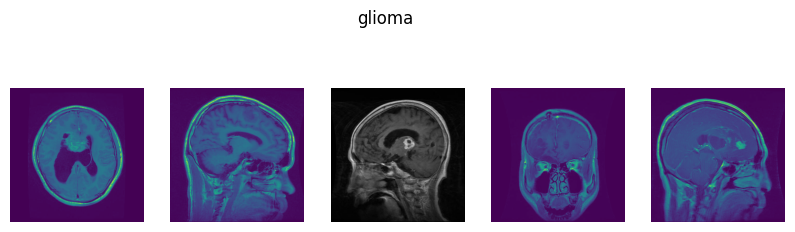

In [3]:
def show_samples(class_name):
    path = os.path.join(TRAIN_PATH, class_name)
    images = os.listdir(path)[:5]

    plt.figure(figsize=(10,3))

    for i, img_name in enumerate(images):
        img_path = os.path.join(path, img_name)
        img = Image.open(img_path)

        plt.subplot(1,5,i+1)
        plt.imshow(img)
        plt.axis('off')

    plt.suptitle(class_name)
    plt.show()

show_samples("glioma")

## 4) Image Preprocessing & Augmentation

We prepare images for training by:
- Resizing images to fixed size (224x224)
- Converting images to tensors
- Normalizing pixel values
- Applying data augmentation (training only)

In [4]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
      transforms.Normalize([0.5, 0.5, 0.5],[0.5, 0.5, 0.5])
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])


## 5) Class Distribution
We check the number of images in each class to understand dataset balance and detect any imbalance that may affect model training.

pituitary: 1457
no_tumor: 1067
meningioma: 1329
glioma: 1147


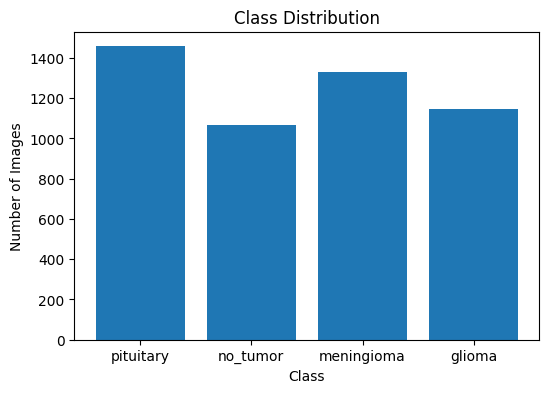

In [5]:
counts = {}
for c in classes:
    path = os.path.join(TRAIN_PATH, c)
    counts[c] = len(os.listdir(path))
    print(f"{c}: {counts[c]}")

plt.figure(figsize=(6,4))
plt.bar(counts.keys(), counts.values())
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

## 6) Custom PyTorch Dataset
This class is responsible for loading images from folders, assigning labels to each class, and applying transformations so the data can be used by PyTorch models.

In [6]:
class BrainTumorDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))

        self.image_paths = []
        self.labels = []

        for label, class_name in enumerate(self.classes):
            class_path = os.path.join(root_dir, class_name)

            for img_name in os.listdir(class_path):
                self.image_paths.append(os.path.join(class_path, img_name))
                self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

## 7) Train / Validation Split
We split training data into train and validation sets.

In [7]:
full_dataset = BrainTumorDataset(TRAIN_PATH, transform=None)
image_paths = full_dataset.image_paths
labels = full_dataset.labels

X_train, X_val, y_train, y_val = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

## 8) Train Dataset Class 
We implemented a custom PyTorch Dataset class to efficiently load MRI images from disk. The class reads images from folder structure, assigns labels based on class names, converts images to RGB format, and applies transformations dynamically during training.

In [8]:
class SplitDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        image = Image.open(self.paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
train_dataset = SplitDataset(X_train, y_train, transform=train_transform)
val_dataset = SplitDataset(X_val, y_val, transform=test_transform)
test_dataset = BrainTumorDataset(TEST_PATH, transform=test_transform)

## 9) DataLoader
DataLoader is used to load data in batches, shuffle training data, and optimize training performance. It ensures efficient GPU utilization and provides mini-batches for training, validation, and testing phases.

In [10]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [11]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


## 10) Save Data
To avoid repeating preprocessing in every run, we saved the processed train/validation splits using PyTorch .pt files. This allows fast loading in future experiments and ensures reproducibility of the dataset split.

In [12]:
os.makedirs("../data/processed", exist_ok=True)
torch.save((X_train, y_train), "../data/processed/train_split.pt")
torch.save((X_val, y_val), "../data/processed/val_split.pt")

# Summary 

###  1) Project Setup & Environment

We started by importing all required libraries for data handling, visualization, and deep learning using PyTorch.

We also checked the execution device (GPU/CPU) to speed up training.

###  2) Dataset Structure Loading

We defined the dataset paths:

- data/raw/train
- data/raw/test

Then we loaded the class names:

- glioma
- meningioma
- no_tumor
- pituitary

This helped us understand the classification problem (4-class brain tumor classification).

###  3) Data Exploration (Basic Check)

We calculated the number of images per class to verify dataset balance:

- glioma: 1147
- meningioma: 1329
- no_tumor: 1067
- pituitary: 1457

This showed that the dataset is slightly imbalanced but acceptable.

We also visualized sample images from each class to confirm data quality.

###  4) Image Preprocessing Strategy

All images were standardized using PyTorch transforms:

Training Transform:
- Resize → 224×224
- Random Horizontal Flip (data augmentation)
- Random Rotation (10°)
- Convert to Tensor
- Normalize (RGB: mean=0.5, std=0.5)
- Testing Transform:
- Resize → 224×224
- Convert to Tensor
- Normalize (same as training)

This ensures consistent input format for the model.

###  5) Dataset Class Creation

We implemented a custom PyTorch Dataset:

- Loads images from folder structure
- Assigns labels based on folder names
- Converts images to RGB format
- Applies transformations dynamically

This allows efficient batch loading during training.

###  6) Train/Validation Split

We split the training dataset into:

- 80% Training set
- 20% Validation set

Using:

train_test_split
stratify = labels (to maintain class balance)

This ensures fair evaluation during training.

###  7) Split Dataset Wrapper

We created a second Dataset class to handle split paths:

- Handles train/validation subsets
- Keeps same transformation pipeline
- Ensures compatibility with DataLoader
###  8) DataLoader Preparation

We created DataLoaders for:

- Training set → shuffled batches
- Validation set → no shuffle
- Test set → evaluation only

Batch size = 32

This enables efficient GPU training.

###  9) Data Format Verification

We verified batch output:

- Images shape: [32, 3, 224, 224]
- Labels shape: [32]

This confirms correct preprocessing and tensor formatting.

###  10) Saving Processed Data

To avoid recomputing preprocessing every time, we saved:

- train_split.pt
- val_split.pt

using PyTorch serialization:

Faster loading in future runs
Ensures reproducibility
Keeps train/val split fixed